## 06-3 주성분 분석

이전에 우리는 k-평균 알고리즘을 이용해서 클러스터로 분류해서 사진들을 폴더별로 저장했다.  
그런데 계속 진행하다 보니 너무 많은 사진이 등로고디어서 저장 공간이 부족해졌다.  
업로드된 사진의 용량을 줄일 수 있는 방법이 있을까?  

---

### 차원과 차원 축소

지금까지 우리는 데이터가 가진 속성을 특성이라고 불렀다.  
과일 사진의 경우 10,000개의 픽셀이 있기 때문에 10,000개의 특성이 존재하는 것이라고 할 수 있다.  
&rArr; 이를 우리는 **차원(dimension)** 이라고 부르는데, 이를 줄일 수 있다면 용량을 크게 줄일 수 있을 것이다.  

<br>

이전에 우리는 특성이 많으면 선형 모델의 성능이 높아지지만,  
그만큼 훈련 데이터에 쉽게 과대적합이 된다는 것을 배웠다.  

&rArr; 차원 죽소(dimension reduction)은 데이터를 가장 잘 나타내는 일부 특성을 선택하여,  
데이터 크기를 줄이고 학습 모델의 성능을 향상시킬 수 있는 방법이다.  
&rArr; 차원 축소의 대표적인 알고리즘인 **주성분 분석(Pricipal component analysis)** 에 대해서 배워보자.

---

### 주성분 분석

주성분 분석은 데이터에 있는 분산이 큰 방향을 찾는 것으로 이해할 수 있다.  

데이터가 많이 퍼져있다는 것은 그 방향으로 분산이 크다는 것을 의미한다.  
즉, PCA는 데이터의 분산을 가장 잘 보존하는 방향을 찾는다.

<br>

첫 번째로 찾은 방향을 **제1주성분** 이라고 한다.  
이 방향은 데이터의 분산이 가장 큰 방향이다.  

그 다음에 제1주성분과 직교하면서, 남은 분산을 가장 잘 설명하는 방향을 찾는데,  
이를 **제2주성분** 이라고 한다.  

정리하면 다음과 같다.
> PCA는 기존 feature 축을 그대로 쓰는 것이 아니라, 데이터의 퍼짐을 가장 잘 설명하는 새로운 축을 찾는 방법이다.

---

### PCA 클래스

!wget https://bit.ly/fruits_300_data -O fruits_300.npy

In [2]:
import numpy as np

fruits = np.load("fruits_300.npy")
fruits_2d = fruits.reshape(-1, 100*100)

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50) # PCA 객체를 만들 때, n_components 매개변수에 주성분 개수를 지정해주어야 한다.
pca.fit(fruits_2d)

print(pca.components_.shape)

(50, 10000)


In [8]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
  n = len(arr) # 샘플 개수

  rows = int(np.ceil(n / 10)) # 한 줄에 10개씩 이미지를 그린다.
  cols = n if rows < 2 else 10 # 행이 1개라면 열의 개수는 샘플 개수이다.

  fig, axs = plt.subplots(rows, cols,
                          figsize=(cols*ratio, rows*ratio), squeeze=False)

  for i in range(rows):
    for j in range(cols):
      if i * 10 + j < n:
        axs[i, j].imshow(arr[i * 10 + j], cmap="gray_r")
        axs[i, j].axis("off")
  plt.show()

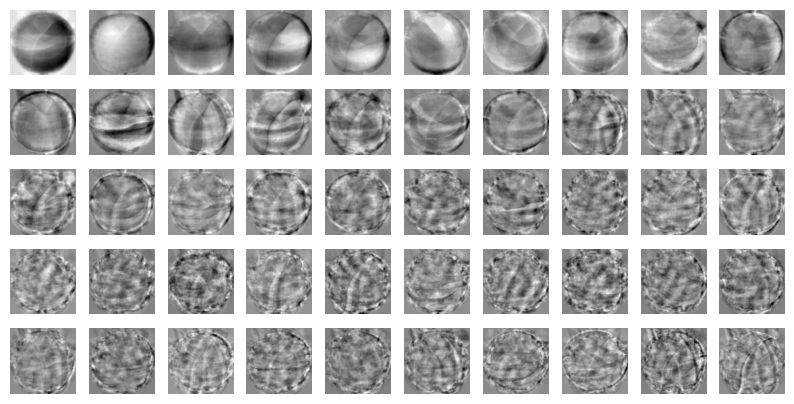

In [9]:
draw_fruits(pca.components_.reshape(-1, 100, 100))

이 주성분들은 이전에 사용했던 `draw_fruits()` 함수를 이용해서 그림으로 표현해 본 것이다.  
원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것이다.  
&rArr; 한편으로는 데이터셋에 있는 어떤 특징을 잡아낸 것으로 생각해 볼 수도 있다.

In [10]:
print(fruits_2d.shape)

fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 10000)
(300, 50)


이전의 `fruits_2d`는 300개의 이미지인데, 10,000개의 픽셀(특성)을 가지고 있었다.  
PCA를 이용해서 차원을 줄인 `fruits_pca`를 살펴보면, 동일한 이미지 300장이지만 50개의 특성을 가진 것을 확인할 수 있다.

---

### 원본 데이터 재구성

10,000개의 특성을 50개로 줄였기 때문에 손실이 발생했을 수 밖에 없을 것이다.  
그래도 최대한 분산이 큰 방향으로 데이터를 투영했으므로,  
다시 데이터를 재구성하는 것도 가능할 것이다.

(300, 10000)


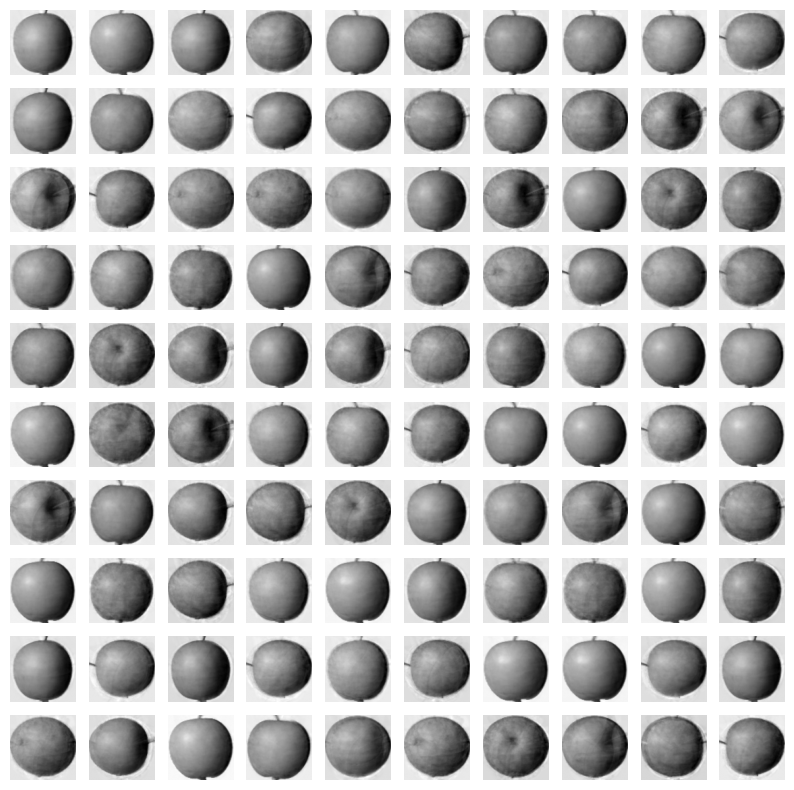

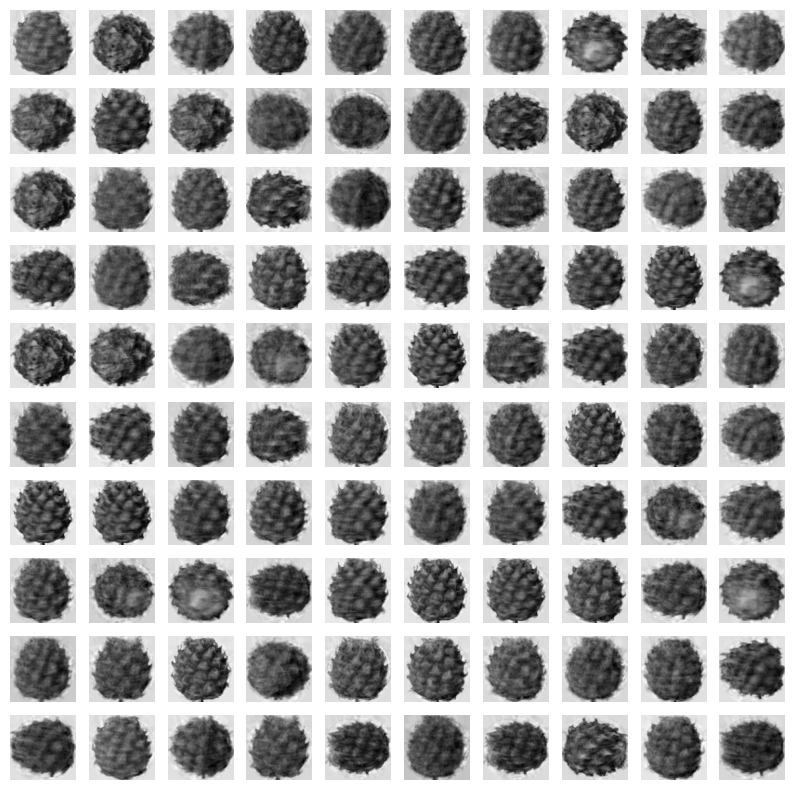

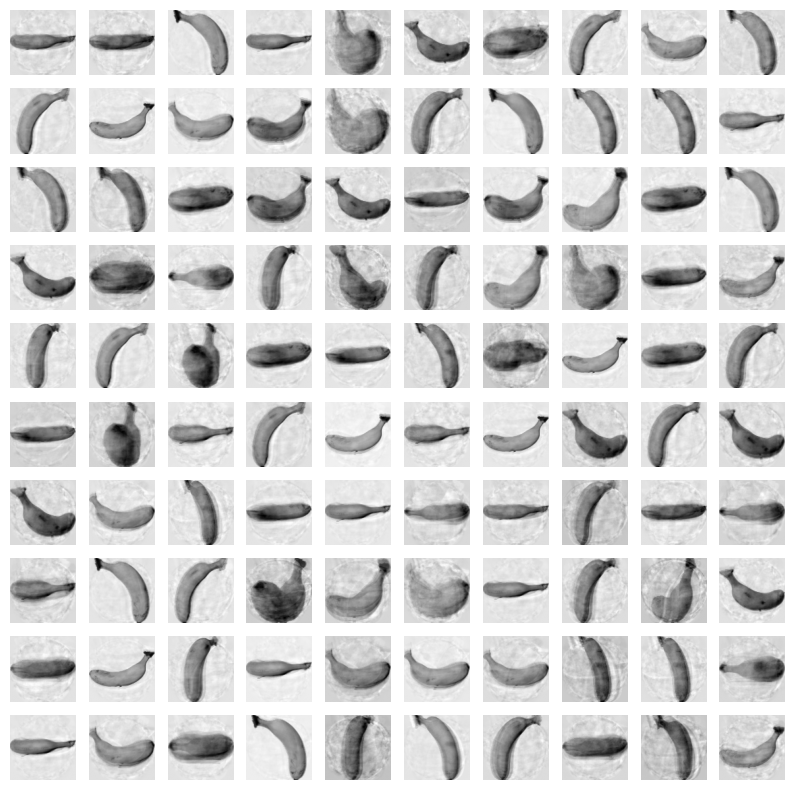

In [14]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print("\n")

일부 흐리고 번진 부분이 있지만 단 50개의 특성만임을 감안한다면 잘 복원된 것을 확인할 수 있다.  

---

### 설명된 분산

주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값을 **설명된 분산(explained variance)** 라고 한다.  

PCA 클래스의 `explained_variance_ratio_`에 각 주성분의 설명된 분산 비율이 기록되어 있다. (당연히 첫 번째 주성분의 비율이 제일 크다.)  
&rArr; 이 분산 비율을 모두 더하면 50개의 주성분으로 표현하고 있는 총 분산 비율을 알 수 있다.  

0.9215036715802574


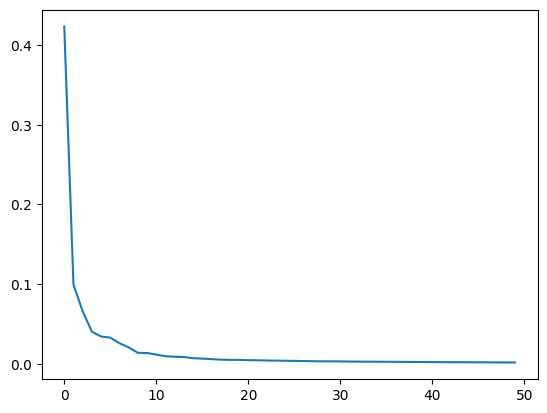

In [16]:
print(np.sum(pca.explained_variance_ratio_))

plt.plot(pca.explained_variance_ratio_)
plt.show()

92%가 넘는 분산을 유지하고 있었다. &rArr; 이미지의 품질이 높았던 이유를 확인할 수 있다.  

그래프로도 그려보면 적절한 주성분의 개수를 찾는 것에 도움이 된다.  
&rArr; 처음 10개의 주성분이 대부분의 분산을 표현하고 있음을 확인할 수 있다.

---

### 다른 알고리즘과 함께 사용하기

지도 학습에도 적용해 보고 어떤 차이가 있는지 확인해보자.

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

# 지도 학습을 위한 타킷값을 만든다.
target = np.array([0] * 100 + [1] * 100 + [2] * 100)

In [19]:
from sklearn.model_selection import cross_validate

scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores["test_score"]))
print(np.mean(scores["fit_time"]))

0.9966666666666667
1.785545253753662


In [20]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores["test_score"]))
print(np.mean(scores["fit_time"]))

0.9966666666666667
0.025682830810546876


pca를 적용하지 않은 로지스틱 회귀의 결과에서도 0.997로 점수가 매우 높게 나온 것으로 확인할 수 있다.  
단, 차이점은 `fit_time`으로 확인할 수 있는 훈련 시간이다.   

50개의 특성만을 이용했음에도 불구하고 정확도는 동일하지만,  
훈련시간은 0.02초로 30배 이상 감소한 것을 확인할 수 있다.

<br>

앞에서는 `n_compnents` 매개변수를 통해서 주성분의 개수를 지정했었다.  
이 대신 원하는 분산의 "비율"을 입력할 수도 있다.

In [22]:
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

print(pca.n_components_)

2


주성분 단 2개로 분산의 50%를 표현할 수 있다.  
단 2개의 주성분을 사용하는 것도 성능이 좋을까?

In [23]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores["test_score"]))
print(np.mean(scores["fit_time"]))


0.9966666666666667
0.04220595359802246


In [24]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


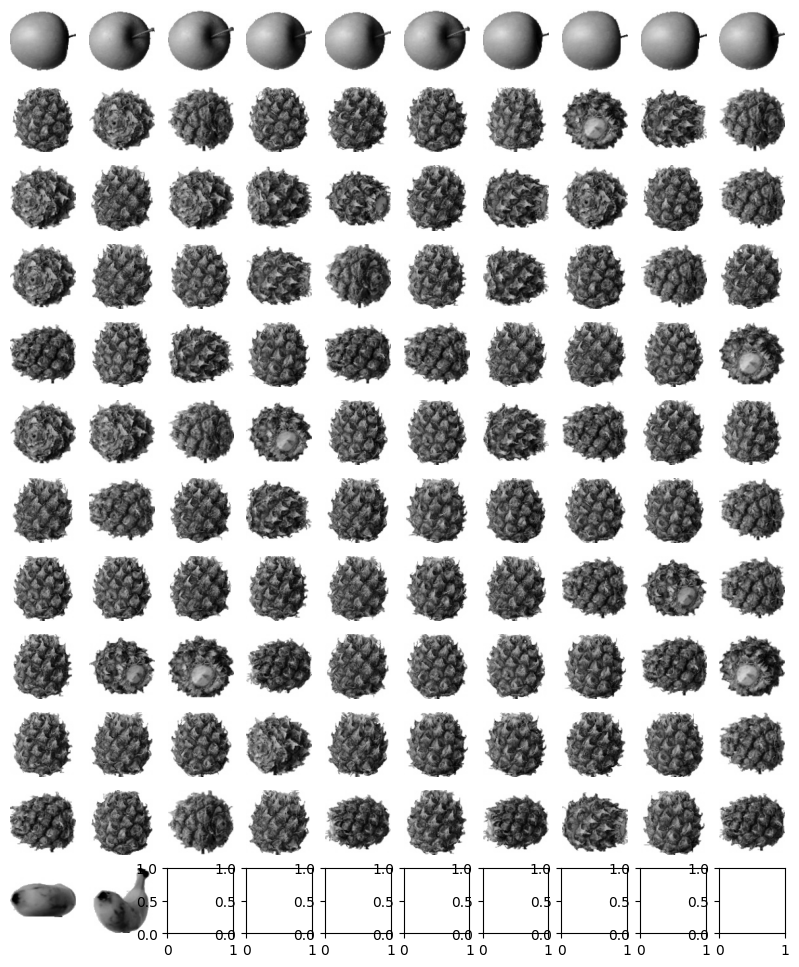

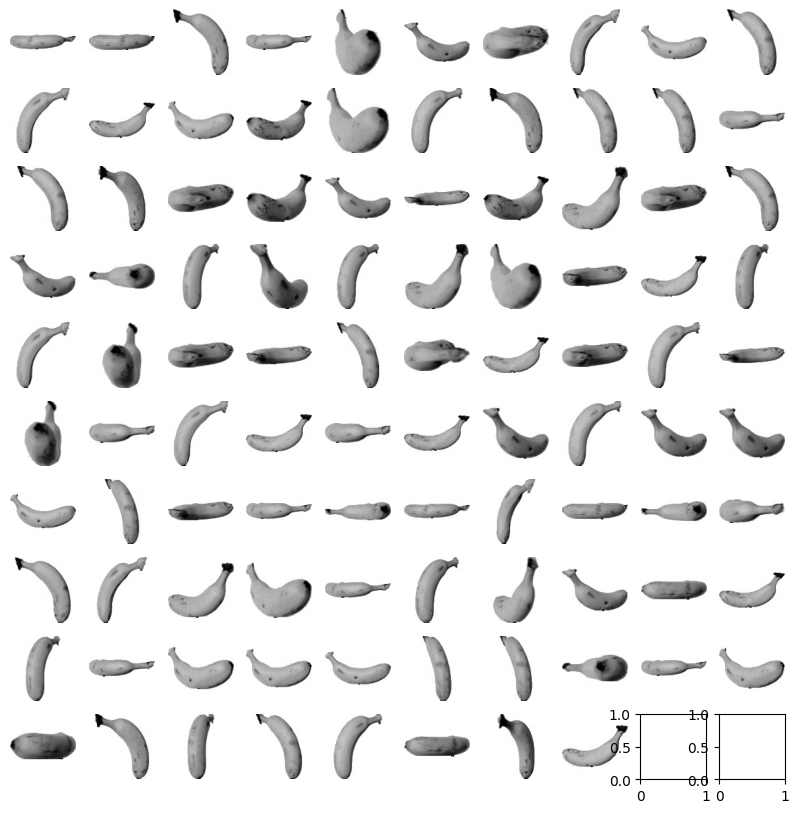

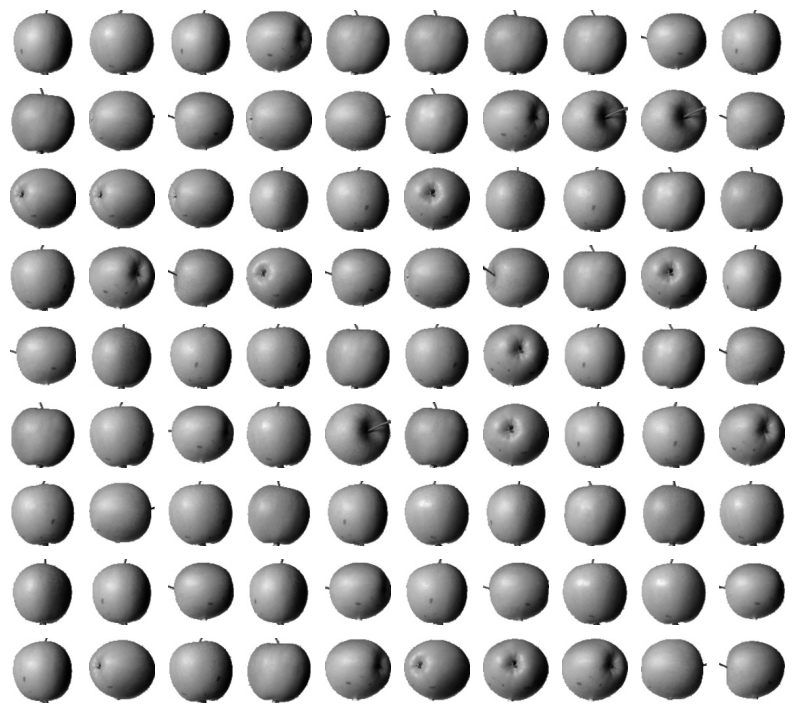

In [26]:
for label in range(0, 3):
  draw_fruits(fruits[km.labels_ == label])
  print("\n")

이전에 해봤던 경우와 유사하게 파인애플과 사과를 혼동하는 경우가 존재한다.

<br>

훈련 데이터의 차원을 줄이면 또 하나 얻을 수 있는 장점은 시각화이다.  
3개 이하로 차원을 줄이면 화면에 출력하기가 쉬워진다.

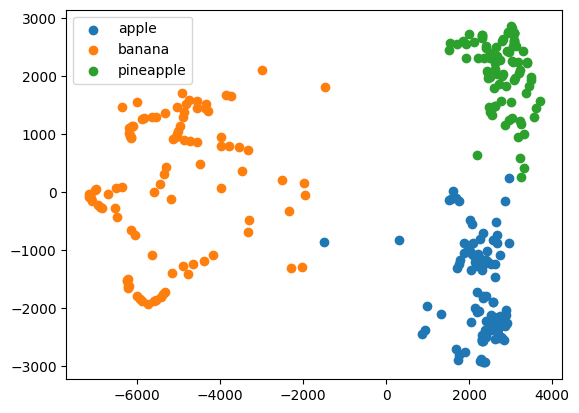

In [27]:
for label in range(0, 3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:, 0], data[:, 1])
plt.legend(["apple", "banana", "pineapple"])
plt.show()

---

대표적인 비지도 학습 문제 중 하나인 **차원 축소(Dimensionality Reduction)** 에 대해서 알아보았다.  

차원 축소는 단순히 데이터의 크기를 줄이는 것 이상의 의미를 가진다.  
고차원 데이터에는 불필요하거나 중복된 정보가 포함되어 있는 경우가 많은데, 차원 축소를 통해 중요한 정보는 최대한 유지하면서 데이터를 더 간결하게 표현할 수 있다.

특히 PCA(Principal Component Analysis)는 데이터의 분산이 큰 방향을 새로운 축으로 삼아 데이터를 표현한다는 점이 인상적이었다.  
기존 feature를 그대로 사용하는 것이 아니라, 데이터가 실제로 가장 많이 퍼져 있는 방향을 기준으로 새로운 좌표계를 만든다는 점에서 단순한 압축 이상의 의미를 가진다고 느꼈다.

또한 차원 축소를 사용하면:

- 데이터 저장 공간 감소
- 연산량 감소
- 학습 속도 향상
- 노이즈 제거 효과
- 과적합 완화 가능성
- 2차원 또는 3차원으로 시각화 가능

등의 장점이 있다는 것도 확인할 수 있었다.

실습에서는 `PCA` 클래스에서 단순히 주성분 개수를 직접 지정하는 방법뿐 아니라,  
“전체 분산의 몇 %를 유지할 것인가”를 기준으로 자동으로 주성분 개수를 선택할 수 있다는 점도 확인했다.

또한 차원 축소된 데이터로부터 원본 데이터를 복원(`inverse_transform`)할 수 있다는 점도 흥미로웠다.  
물론 일부 정보 손실은 발생하지만, 중요한 분산 정보가 유지된다면 원본의 특징을 상당 부분 복원할 수 있었다.

특히 이를 통해 다음과 같은 사실을 느낄 수 있었다.

> 데이터의 모든 정보가 항상 중요한 것은 아니다.

실제로는 일부 핵심적인 패턴이나 구조가 데이터를 대부분 설명하고 있으며, PCA는 바로 그 핵심 구조를 찾아내는 과정에 가깝다는 것을 이해하게 되었다.

앞으로는 단순히 PCA를 사용하는 것에서 끝나는 것이 아니라:

- 어떤 상황에서 PCA가 효과적인지
- PCA가 잘 동작하지 않는 경우는 언제인지
- 스케일링이 왜 중요한지
- 분산이 크다는 것이 정말 중요한 정보를 의미하는지
- 비선형 차원 축소(`t-SNE`, `UMAP`)와는 어떤 차이가 있는지

까지 함께 비교하며 학습해보고 싶다.